# When is inverse-variance weighting useful?

## A situation where inverse-variance weighting is useless

Let's import our libraries first.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Imagine a temperature sensor that only works occasionally and sends you the data when it's active. We can simulate this situation by having a fake data and only working with it's samples.

In [2]:
data = np.random.normal(50, 100, 1000)
data[:5]

array([-14.56890446, 130.50191151, -23.03524033, 116.58369062,
        86.5243811 ])

Let's also see how the actual data looks like in a KDE plot.

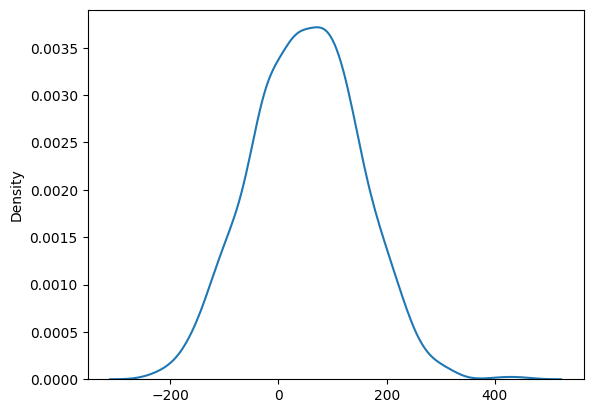

In [3]:
fig, ax = plt.subplots()
sns.kdeplot(data, ax=ax)
plt.show()

In [4]:
samples = []
for _ in range(20):
    samples.append(np.random.choice(data, 20))

samples[:5]

[array([ 206.78961654,   57.45294469,   69.54290603,  -50.25164989,
         117.1440463 ,   96.34647658,  129.396505  , -149.94277316,
         213.56186487,  -27.81694189,  -12.83830787, -101.82815955,
          61.2026088 ,  -14.58389292,  242.15958721,   53.83954912,
         -59.38732137,   49.51887008,    4.22596117,   19.68182446]),
 array([  89.25750702,   18.43714281,  128.43308763,   85.37011214,
         186.00721092,   61.41344483,  -29.67508321,  -10.80271235,
         174.65770067,  196.62425365,   79.92832751,  -55.05838448,
         -59.37925311,   71.82848294,  107.82438556,   35.91246717,
        -139.68060444,  108.30791672,   97.86185543,  137.11812843]),
 array([  85.37011214,   53.22844703,   34.1698131 ,   -9.82633686,
          81.17760471,  143.8746859 ,  -83.08543984,   43.41224143,
        -176.5254705 ,   20.01050859,  227.88448445,   63.33145818,
          57.32718197,   49.51887008,  117.1440463 ,  -87.77583892,
        -107.71571397,  182.20700596, -165.3

And here we have 20 samples from the population data.

In [5]:
for i, s in enumerate(samples, 1):
    print(f"Var of {i}:", np.var(s), f"| Mean of {i}:", np.mean(s))
    print()

Var of 1: 10178.731813153512 | Mean of 1: 45.21068570984515

Var of 2: 7439.109125349892 | Mean of 2: 64.21929929295099

Var of 3: 11135.78182147186 | Mean of 3: 24.93831997793351

Var of 4: 4262.635482311239 | Mean of 4: 52.90194214431551

Var of 5: 7673.121709079552 | Mean of 5: 29.644970858944827

Var of 6: 8839.679828113942 | Mean of 6: 22.883895427649044

Var of 7: 11052.505604753174 | Mean of 7: 23.93028954254823

Var of 8: 16167.336515279574 | Mean of 8: 53.76287493080848

Var of 9: 9480.356431592056 | Mean of 9: 28.24100094271434

Var of 10: 9773.273493629284 | Mean of 10: 50.65287176381457

Var of 11: 11148.668174487448 | Mean of 11: 44.95454381389707

Var of 12: 9561.534702492514 | Mean of 12: 53.05300887857353

Var of 13: 8619.041406728265 | Mean of 13: 59.760787332153484

Var of 14: 7112.040064171562 | Mean of 14: 54.70759118859362

Var of 15: 7189.638910167972 | Mean of 15: 46.268729071644266

Var of 16: 10333.840169927806 | Mean of 16: 26.965571152472876

Var of 17: 10490

We can show the mean and the variance of these samples in a beautiful `pandas` data frame. It is also going to make it easier for us to work with parameters of the samples.

In [6]:
data_sum = pd.DataFrame(
    {
        "mean": [np.mean(s) for s in samples],
        "var": [np.var(s) for s in samples],
        "weights": [1 / np.var(s) for s in samples],
    }
)
data_sum

,mean,var,weights
0,45.210686,10178.731813,0.000098
1,64.219299,7439.109125,0.000134
2,24.938320,11135.781821,0.000090
3,52.901942,4262.635482,0.000235
4,29.644971,7673.121709,0.000130
5,22.883895,8839.679828,0.000113
6,23.930290,11052.505605,0.000090
7,53.762875,16167.336515,0.000062
8,28.241001,9480.356432,0.000105
9,50.652872,9773.273494,0.000102


Here we can also see a column called `weights`, it is calculated by taking the reciprocal of variance ($\frac{1}{\sigma^2}$). We are going to use this weights to calculate the weighted mean, which we expect to yield better results.

In [7]:
weighted_mean = np.sum(data_sum["weights"] * data_sum["mean"]) / np.sum(
    data_sum["weights"]
)

In [8]:
actual_mean = np.mean(data)
print("Actual mean:", actual_mean)
print("Weighted mean:", weighted_mean)
print("Grand mean:", np.mean(data_sum["mean"]))

Actual mean: 50.10874701111742
Weighted mean: 43.12405659712762
Grand mean: 41.3782447797974


As you can see in the results, _grand mean_ is giving us a better result compared to _weighted mean_. This is because we are using the same distribution, or same sensor, for sampling. When we draw samples from the same distribution, since the “uncertainity” of the samples remains the same, there is no point in using the weighted mean.

## A situation where inverse-variance weighting is useful

You can think of this actual mean as the actual temperature of a room.

In [9]:
actual_mean = 30

Below, we simulated different sensors with different variances (or in this context, different quailities). But because the temperature of the room cannot change from sensor to sensor, it remains the same (`actual_mean`).

In [10]:
samples_from_different_dists = []

samples_from_different_dists.append(np.random.normal(actual_mean, 10, 10))
samples_from_different_dists.append(np.random.normal(actual_mean, 40, 10))

# Adding a lot of bad sensors to prove a point :D
samples_from_different_dists.append(np.random.normal(actual_mean, 150, 10))
samples_from_different_dists.append(np.random.normal(actual_mean, 150, 10))

We created the same `pandas` data frame the see the results clearly. But here, difference between weights are more noticeable. Because we rely more on the low-variance sensor, while also taking the high-variance sensor's data into account.

In [11]:
different_data_sum = pd.DataFrame(
    {
        "mean": [np.mean(s) for s in samples_from_different_dists],
        "var": [np.var(s) for s in samples_from_different_dists],
        "weights": [1 / np.var(s) for s in samples_from_different_dists],
    }
)
different_data_sum

,mean,var,weights
0,29.462682,94.038845,0.010634
1,43.948102,1645.513349,0.000608
2,23.384459,14960.007505,0.000067
3,5.537193,30383.152989,0.000033


In [12]:
weighted_mean_diff = np.sum(
    different_data_sum["mean"] * different_data_sum["weights"]
) / np.sum(different_data_sum["weights"])
weighted_mean_diff

np.float64(30.133608209608763)

Here, the weighted mean calculated with IVW method is much closer to the actual mean than the grand mean because we are using different distributions (sensors) with different variances.

In [13]:
print("Actual mean:", actual_mean)
print("Weighted mean:", weighted_mean_diff)
print("Grand mean:", np.mean(different_data_sum["mean"]))

Actual mean: 30
Weighted mean: 30.133608209608763
Grand mean: 25.583109098887892


You may also ask why should we bother with high-variance data if we already have a decent low-variance data. The answer to this question is: **Data is data**, no matter what. In most scenarios, using high-variance data and giving it less weight is much more appropriate methodology than not using it at all.